# Optimasi dan Regularisasi pada Jaringan Saraf Tiruan (Deep Learning)

Pelatihan jaringan saraf tiruan (Artificial Neural Network/ANN) yang dalam dan kompleks dengan ribuan atau jutaan parameter memerlukan teknik khusus. Jika hanya mengandalkan algoritme dasar seperti Gradient Descent murni, proses pelatihan akan memakan waktu sangat lama dan rentan terjebak pada sub-optimal. Di sisi lain, model dengan parameter masif sangat berisiko mengalami **overfitting** (terlalu menghafal data latih). 

Bab ini merangkum teknik **Optimasi** (untuk mempercepat konvergensi dan menemukan nilai minimum global) serta **Regularisasi** (untuk mencegah overfitting).

## 1. Optimasi Gradient Descent

Cost function pada jaringan saraf sangat rumit akibat penggunaan fungsi aktivasi non-linier (seperti Sigmoid atau ReLU) di berbagai layer. Hal ini menciptakan permukaan error yang tidak cembung (*non-convex surface*) yang dipenuhi lembah, bukit, dan *saddle points*.

[Image of non-convex optimization surface gradient descent]

### 1.1 Stochastic Gradient Descent (SGD) dengan Momentum
SGD murni sering kali mengalami kesulitan saat melewati area landai (saddle point) atau terjebak di *local minimum*. Selain itu, pembaruan bobot hanya mengandalkan gradien sesaat, yang bisa menyebabkan pergerakan lambat atau osilasi.

**Konsep Momentum:** Layaknya bola yang menggelinding menuruni bukit, momentum mengakumulasi kecepatan berdasarkan gradien-gradien sebelumnya. Ini mendorong "bola" terus maju melewati area landai atau mendaki bukit kecil untuk keluar dari *local minimum*.

Persamaan pembaruan bobot dengan Momentum:
$$m_t = \beta \times m_{t-1} - \eta \times \nabla w_{t-1}$$
$$w_t = w_{t-1} + m_t$$

Di mana:
* $t$ = epoch ke-$t$
* $m_t$ = momentum saat ini (akumulasi gradien)
* $\eta$ = *learning rate*
* $\nabla w_{t-1}$ = gradien pada epoch sebelumnya
* $\beta$ = koefisien momentum (umumnya 0.9)

**Perhitungan Ekspansi Momentum:**
Misalkan $m_0 = 0$, $\beta = 0.9$, dan gradien sesaat adalah $G_t$:
$$m_1 = -G_0$$
$$m_2 = -0.9 \times G_0 - G_1$$
$$m_3 = 0.9 \times (-0.9 \times G_0 - G_1) - G_2 = -0.81G_0 - 0.9G_1 - G_2$$
$$m_4 = -0.729G_0 - 0.81G_1 - 0.9G_2 - G_3$$

Bisa dilihat bahwa momentum merupakan *moving average* dari gradien masa lalu, di mana gradien yang lebih lama memiliki pengaruh yang meluruh secara eksponensial.

### 1.2 Root Mean Square Propagation (RMSProp)
Masalah lain pada jaringan dalam adalah *Vanishing/Exploding Gradients* (gradien menghilang atau membludak). RMSProp mengatasi hal ini dengan menggunakan *learning rate* adaptif untuk setiap parameter.

RMSProp membagi *learning rate* dengan *moving exponential average* dari kuadrat gradien masa lalu. Jika gradien tiba-tiba membesar, pembaginya ikut membesar (langkah diperkecil). Jika gradien mengecil, pembaginya mengecil (langkah diperbesar).

Persamaan RMSProp:
$$s_t = \beta \times s_{t-1} + (1 - \beta) \times (\nabla w_{t-1})^2$$
$$w_t = w_{t-1} - \frac{\eta}{\sqrt{s_t} + \epsilon} \times \nabla w_{t-1}$$

**Perhitungan Ekspansi RMSProp:**
Dengan $s_0 = 0$ dan $\beta = 0.9$:
$$s_1 = 0.1 \times (\nabla w_0)^2$$
$$s_2 = 0.9 \times (0.1 \times (\nabla w_0)^2) + 0.1 \times (\nabla w_1)^2$$
Secara umum dapat ditulis:
$$s_t = (1 - \beta) \sum_{l=1}^t \beta^{t-l} \times (\nabla w_{l-1})^2$$

### 1.3 Adaptive Moment Estimation (ADAM)
ADAM adalah kombinasi kekuatan **Momentum** (melacak rata-rata gradien untuk melewati *local minima*) dan **RMSProp** (melacak rata-rata kuadrat gradien untuk meredam osilasi).

Langkah algoritme ADAM (dengan nilai default $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$):
1. Menghitung momentum (rata-rata gradien):
   $$m_t = \beta_1 \times m_{t-1} + (1 - \beta_1) \times \nabla w_{t-1}$$
2. Menghitung RMS (rata-rata kuadrat gradien):
   $$s_t = \beta_2 \times s_{t-1} + (1 - \beta_2) \times (\nabla w_{t-1})^2$$
3. Koreksi bias untuk momentum (karena $m_0 = 0$):
   $$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$
4. Koreksi bias untuk RMS (karena $s_0 = 0$):
   $$\hat{s}_t = \frac{s_t}{1 - \beta_2^t}$$
5. Pembaruan bobot:
   $$w_t = w_{t-1} - \frac{\eta}{\sqrt{\hat{s}_t} + \epsilon} \times \hat{m}_t$$

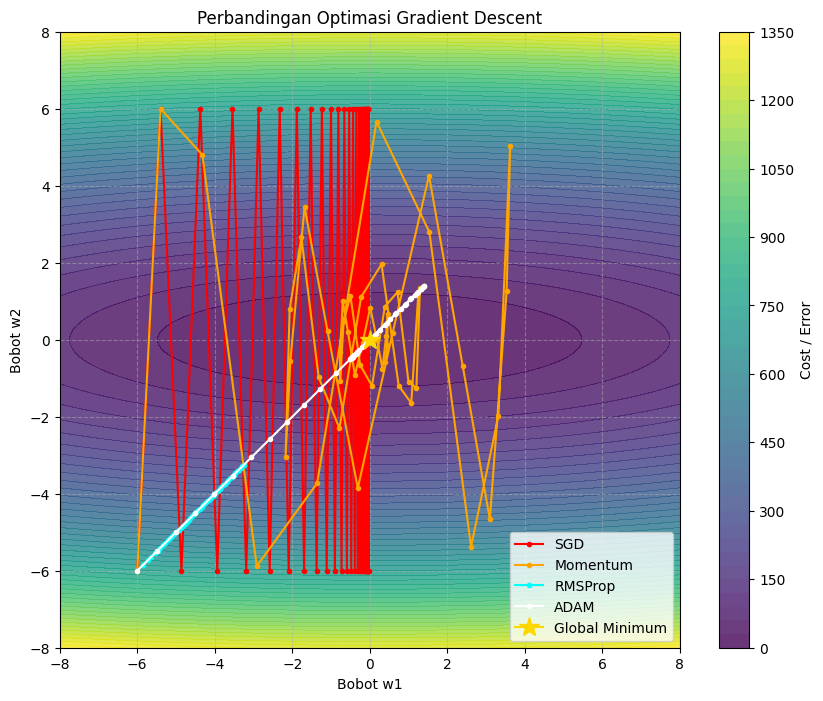

In [1]:
# Sel Kode 1: Visualisasi Lintasan Optimasi (SGD, Momentum, RMSProp, Adam)
import numpy as np
import matplotlib.pyplot as plt

# Definisi fungsi non-convex sederhana (fungsi parabolik melengkung)
def f(x, y):
    return x**2 + 20*y**2

# Turunan parsial terhadap x dan y
def grad_f(x, y):
    return np.array([2*x, 40*y])

# Konfigurasi simulasi
start_point = np.array([-6.0, -6.0])
epochs = 50
learning_rate = 0.05

# Inisialisasi lintasan
path_sgd = [start_point]
path_momentum = [start_point]
path_rmsprop = [start_point]
path_adam = [start_point]

# 1. SGD Murni
w = start_point.copy()
for _ in range(epochs):
    w = w - learning_rate * grad_f(w[0], w[1])
    path_sgd.append(w.copy())

# 2. SGD Momentum
w = start_point.copy()
m = np.zeros(2)
beta = 0.9
for _ in range(epochs):
    grad = grad_f(w[0], w[1])
    m = beta * m - learning_rate * grad
    w = w + m
    path_momentum.append(w.copy())

# 3. RMSProp
w = start_point.copy()
s = np.zeros(2)
beta_rms = 0.9
epsilon = 1e-8
for _ in range(epochs):
    grad = grad_f(w[0], w[1])
    s = beta_rms * s + (1 - beta_rms) * (grad**2)
    w = w - (learning_rate / (np.sqrt(s) + epsilon)) * grad
    path_rmsprop.append(w.copy())

# 4. ADAM
w = start_point.copy()
m = np.zeros(2)
s = np.zeros(2)
beta1, beta2 = 0.9, 0.999
learning_rate_adam = 0.5 # Adam sering butuh LR berbeda di simulasi toy
for t in range(1, epochs + 1):
    grad = grad_f(w[0], w[1])
    m = beta1 * m + (1 - beta1) * grad
    s = beta2 * s + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    s_hat = s / (1 - beta2**t)
    w = w - (learning_rate_adam / (np.sqrt(s_hat) + epsilon)) * m_hat
    path_adam.append(w.copy())

# Konversi ke array untuk plotting
paths = {
    'SGD': np.array(path_sgd),
    'Momentum': np.array(path_momentum),
    'RMSProp': np.array(path_rmsprop),
    'ADAM': np.array(path_adam)
}

# Membuat Contour Plot
x = np.linspace(-8, 8, 400)
y = np.linspace(-8, 8, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(label='Cost / Error')

colors = {'SGD': 'red', 'Momentum': 'orange', 'RMSProp': 'cyan', 'ADAM': 'white'}
for name, path in paths.items():
    plt.plot(path[:, 0], path[:, 1], marker='o', markersize=3, label=name, color=colors[name])

plt.plot(0, 0, marker='*', color='gold', markersize=15, label='Global Minimum')
plt.title("Perbandingan Optimasi Gradient Descent")
plt.xlabel("Bobot w1")
plt.ylabel("Bobot w2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2. Regularisasi Jaringan

Jaringan saraf dengan parameter yang sangat banyak memiliki derajat kebebasan (*degrees of freedom*) yang luar biasa. Ini membuatnya mudah memodelkan kompleksitas, namun juga sangat rentan terhadap *overfitting* (hanya hafal data latih tapi gagal di data baru).

### 2.1 Dropout
Pada setiap epoch, neuron pada hidden layer memiliki probabilitas $p$ (biasanya 0.1 hingga 0.5) untuk "dimatikan" sementara. 



**Mengapa Dropout bekerja?**
1. Mencegah ko-adaptasi: Neuron tidak bisa bergantung pada neuron tetangga tertentu karena tetangganya bisa saja mati. Tiap neuron dipaksa belajar fitur yang berguna secara mandiri.
2. Robus terhadap noise: Neuron tidak bisa terlalu sensitif terhadap beberapa input saja, menyebar pembobotan, dan menciptakan jaringan yang menggeneralisasi lebih baik.

### 2.2 Batch Normalization (Batchnorm)
Meskipun fitur input telah dinormalisasi di awal, saat data mengalir ke dalam layer-layer tersembunyi, penerapan aktivasi non-linier dan perkalian matriks akan menggeser distribusi nilai-nilai aktivasi. Ini disebut **Internal Covariate Shift Problem**.

Batchnorm menjamin aliran data tetap dalam distribusi normal di sepanjang internal layer.

**Langkah Normalisasi Batchnorm pada Mini-Batch:**
Misalkan suatu mini-batch berisi input $x^{(1)}, x^{(2)}, \dots, x^{(m)}$ dengan dimensi variabel ke-$l$:

1. Hitung rata-rata:
   $$\mu_l = \frac{1}{m} \sum_{v=1}^m x_l^{(v)}$$
2. Hitung deviasi standar:
   $$\sigma_l = \sqrt{ \frac{1}{m} \sum_{v=1}^m (x_l^{(v)} - \mu_l)^2 }$$
3. Normalisasi variabel ($z$-score):
   $$g_l^{(v)} = \frac{x_l^{(v)} - \mu_l}{\sigma_l}$$
4. *Scaling* dan *Shifting* (di mana $\gamma$ dan $\beta$ adalah parameter yang dipelajari mesin):
   $$g_l'^{(v)} = \gamma \times g_l^{(v)} + \beta$$

*Catatan penting: Karena Dropout mengacak neuron yang aktif dan Batchnorm sangat bergantung pada statistik dari sekumpulan neuron aktif, umumnya sangat **tidak disarankan** menggunakan Dropout dan Batchnorm pada lapisan jaringan yang persis sama secara bersamaan.*

In [2]:
# Sel Kode 2: Simulasi Perhitungan Normalisasi Manual dan Implementasi Pandas
import pandas as pd
import numpy as np

# Data mentah
data = {
    'Tinggi': [1.75, 1.80, 1.83, 1.83],
    'Gaji': [2320044, 79568, 32742000, 33296296]
}

df = pd.DataFrame(data)

# Fungsi perhitungan normalisasi secara matematis sesuai ekuasi di bab
def manual_normalization(series):
    # 1. Hitung mean (mu)
    mu = sum(series) / len(series)
    
    # 2. Hitung standard deviation (sigma) populasi
    variance = sum((x - mu)**2 for x in series) / len(series)
    sigma = np.sqrt(variance)
    
    # 3. Normalisasi (z-score)
    normalized = [(x - mu) / sigma for x in series]
    return mu, sigma, np.round(normalized, 1) # dibulatkan 1 angka di belakang koma untuk kemiripan tabel

mu_tinggi, sigma_tinggi, norm_tinggi = manual_normalization(df['Tinggi'])
mu_gaji, sigma_gaji, norm_gaji = manual_normalization(df['Gaji'])

df['Tinggi (norm)'] = norm_tinggi
df['Gaji (norm)'] = norm_gaji

print(f"Perhitungan Manual Statistik Tinggi:")
print(f"Mu = {mu_tinggi:.2f}, Sigma = {sigma_tinggi:.2f}\n")
print(f"Perhitungan Manual Statistik Gaji:")
print(f"Mu = {mu_gaji:,.0f}, Sigma = {sigma_gaji:,.0f}\n")

print("Tabel Normalisasi:")
display(df)

Perhitungan Manual Statistik Tinggi:
Mu = 1.80, Sigma = 0.03

Perhitungan Manual Statistik Gaji:
Mu = 17,109,477, Sigma = 15,930,584

Tabel Normalisasi:


,Tinggi,Gaji,Tinggi (norm),Gaji (norm)
0,1.75,2320044,-1.6,-0.9
1,1.80,79568,-0.1,-1.1
2,1.83,32742000,0.8,1.0
3,1.83,33296296,0.8,1.0


## 3. Petunjuk Pembuatan, Pelatihan Jaringan, dan Ukuran Dataset

### 3.1 Praktik Terbaik (Best Practices) Arsitektur Jaringan
Berdasarkan studi kasus (misalnya Fashion-MNIST) dan teori, berikut panduannya:
1. **Mulai secara dangkal**: Mulailah dari 1 atau 2 *hidden layer*. Hanya tambah kedalaman jika performa masih kurang.
2. **Bentuk Corong (Funnel)**: Jumlah neuron umumnya menurun semakin dalam layernya karena fitur makin terenkapsulasi.
3. **Fungsi Aktivasi**: **ReLU** sangat dianjurkan untuk *hidden layers* guna menghindari masalah komputasi lambat dan *vanishing gradient*. Output layer sesuaikan dengan masalah (*Softmax* untuk klasifikasi multi-kelas, *Sigmoid* untuk klasifikasi biner).
4. **Cegah Overfitting**: Selalu gunakan pemisahan data (*Training Set* & *Test/Validation Set*). Gunakan *Optimizer* canggih (seperti ADAM) yang dikombinasikan dengan teknik Regularisasi (Dropout atau Batchnorm).
5. **Kinerja Tidak Linear**: Menambah kedalaman (*layer*) secara sembarangan justru bisa **menurunkan** akurasi model jika *dataset* tidak memadai atau fenomena *overfitting* tidak tertangani.

### 3.2 Ukuran Dataset (*Training Set*)
Aturan praktis minimum:
* **Model Linear**: Butuh minimal $10 \times \text{dimensi input}$ sampel latih.
* **Jaringan Saraf Tiruan (Deep Learning)**: Dimensi diukur dari parameter bobot (bisa jutaan). Aturan umumnya adalah **1.000 hingga 10.000 sampel minimum**. Untuk industri nyata (*real-world critical apps*), gunakan skala **ratusan ribu hingga jutaan** example data latih agar performa jaringan benar-benar *robust* dan *reliable*.

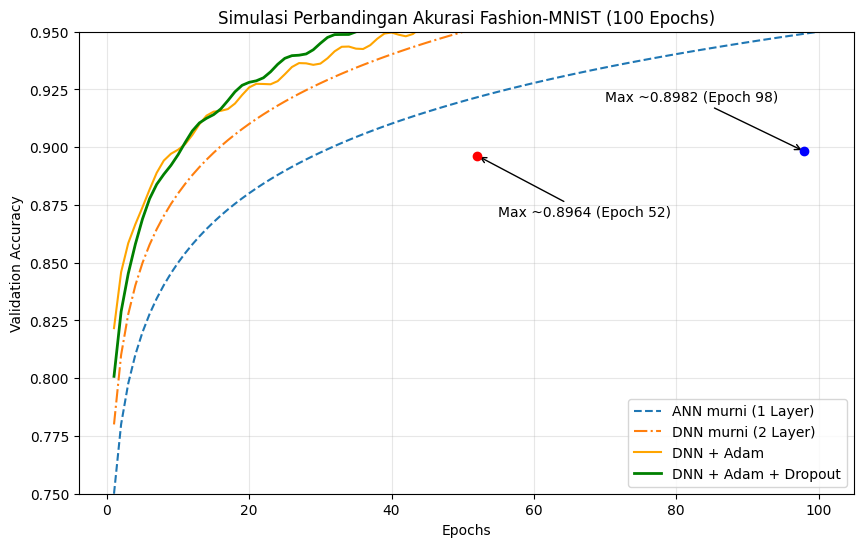

In [3]:
# Sel Kode 3: Visualisasi Studi Kasus Fashion MNIST (Plot Perbandingan Akurasi)
import matplotlib.pyplot as plt
import numpy as np

# Simulasi data mock-up berdasar teks (Akurasi melandai di epoch tinggi)
epochs = np.arange(1, 101)

# Persamaan logaritmik sederhana untuk mensimulasikan kurva belajar (learning curve)
acc_ann = 0.75 + 0.10 * np.log10(epochs)  # ANN Murni
acc_dnn = 0.78 + 0.10 * np.log10(epochs)  # DNN Murni
acc_dnn_adam = 0.82 + 0.08 * np.log10(epochs) # DNN Adam (mencapai ~0.8964 di pertengahan)
acc_dnn_adam_drop = 0.80 + 0.098 * np.log10(epochs) # DNN Adam + Dropout (mencapai ~0.8982 perlahan)

# Menambahkan sedikit noise osilasi kecil
acc_dnn_adam += np.sin(epochs) * 0.002
acc_dnn_adam_drop += np.cos(epochs) * 0.0015

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc_ann, label='ANN murni (1 Layer)', linestyle='--')
plt.plot(epochs, acc_dnn, label='DNN murni (2 Layer)', linestyle='-.')
plt.plot(epochs, acc_dnn_adam, label='DNN + Adam', color='orange')
plt.plot(epochs, acc_dnn_adam_drop, label='DNN + Adam + Dropout', color='green', linewidth=2)

# Marking the peaks mentioned in text
plt.scatter(52, 0.8964, color='red', zorder=5)
plt.annotate('Max ~0.8964 (Epoch 52)', xy=(52, 0.8964), xytext=(55, 0.87),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.scatter(98, 0.8982, color='blue', zorder=5)
plt.annotate('Max ~0.8982 (Epoch 98)', xy=(98, 0.8982), xytext=(70, 0.92),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.title('Simulasi Perbandingan Akurasi Fashion-MNIST (100 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim(0.75, 0.95)
plt.show()